# This script analyzes how different the solutions are for different $n_e$ presences in the bc and ig

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [15]:
# Testing betan for fixed case
fix_path = '/mnt/homes_global/jal2351/software/saarelma-conner-ped/tests/convergence/eped_loop_converg_ne_fix/'
fix_equil = fix_path + '152960.03500'
fix_test = []
for i in range(0,8):
    # np.save(dict) loads as a 0-d object array; .item() unwraps to the dict
    fix_sol = np.load(fix_equil + f'/ne_and_Te_iter_{i}.npy', allow_pickle=True).item()
    fix_test.append(fix_sol)
    print(fix_sol['betan'])

-1
[1.15972381]
[1.50788537]
[1.5490648]
[1.55909553]
[1.56163433]
[1.56218386]
[1.5624114]


In [16]:
# Testing betan for bc case
bc_path = '/mnt/homes_global/jal2351/software/saarelma-conner-ped/tests/convergence/eped_loop_converg_ne_bc/'
bc_equil = bc_path + '152960.03500'
bc_test = []
for i in range(0,8):
    # np.save(dict) loads as a 0-d object array; .item() unwraps to the dict
    bc_sol = np.load(bc_equil + f'/ne_and_Te_iter_{i}.npy', allow_pickle=True).item()
    bc_test.append(bc_sol)
    print(bc_sol['betan'])

-1
[1.15972381]
[0.96078013]
[0.91741961]
[0.90440497]
[0.89970317]
[0.89822547]
[0.89802186]


In [17]:
# Testing betan for bcig case
bc_path = '/mnt/homes_global/jal2351/software/saarelma-conner-ped/tests/convergence/eped_loop_converg_ne_bc_and_ig/'
bc_equil = bc_path + '152960.03500'
bc_test = []
for i in range(0,8):
    # np.save(dict) loads as a 0-d object array; .item() unwraps to the dict
    bc_sol = np.load(bc_equil + f'/ne_and_Te_iter_{i}.npy', allow_pickle=True).item()
    bc_test.append(bc_sol)
    print(bc_sol['betan'])

-1
[1.15972381]
[0.96078013]
[0.91739521]
[0.9044207]
[0.89967544]
[0.89820131]
[0.8980304]


# Compare $n_e, T_e,$ and $p$

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


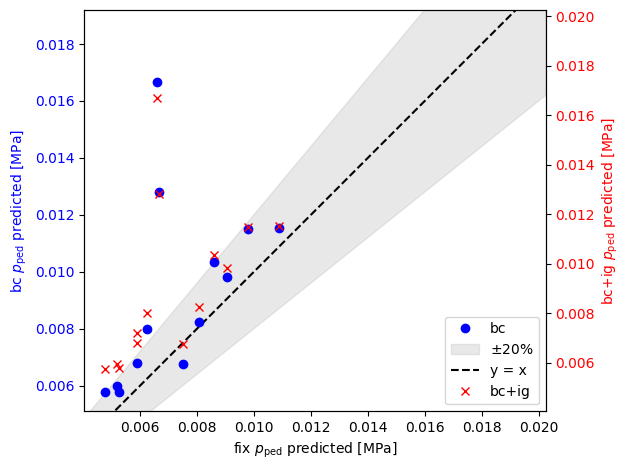

bc points (14): ['152960.03500', '153032.04475', '153140.04750', '153153.03800', '153303.03100', '153485.03500', '153489.01800', '153646.04200', '153651.03900', '153659.04350', '153661.04100', '153702.03950', '153778.02170', '153783.02600']
bc+ig points (14): ['152960.03500', '153032.04475', '153140.04750', '153153.03800', '153303.03100', '153485.03500', '153489.01800', '153646.04200', '153651.03900', '153659.04350', '153661.04100', '153702.03950', '153778.02170', '153783.02600']


In [2]:
# Predicted pedestal-top pressure (ped_h): bc & bc+ig vs fix
import os

base = '/mnt/homes_global/jal2351/software/saarelma-conner-ped/tests/convergence/'
bc_dir = base + 'eped_loop_converg_ne_bc/'
bcig_dir = base + 'eped_loop_converg_ne_bc_and_ig/'
fix_dir = base + 'eped_loop_converg_ne_fix/'

def load_ped_h(run_dir):
    """Return {equil_id: ped_h} for equilibria with success_outdict.npy."""
    out = {}
    for name in sorted(os.listdir(run_dir)):
        fpath = os.path.join(run_dir, name, 'success_outdict.npy')
        if os.path.isfile(fpath):
            od = np.load(fpath, allow_pickle=True).item()
            out[name] = float(od['ped_h'])
    return out

bc_ped = load_ped_h(bc_dir)
bcig_ped = load_ped_h(bcig_dir)
fix_ped = load_ped_h(fix_dir)

# Match successful equilibria to the fix case for each y-series
bc_tags = sorted(set(bc_ped) & set(fix_ped))
bcig_tags = sorted(set(bcig_ped) & set(fix_ped))

fix_bc = np.array([fix_ped[t] for t in bc_tags])
bc_vals = np.array([bc_ped[t] for t in bc_tags])
fix_bcig = np.array([fix_ped[t] for t in bcig_tags])
bcig_vals = np.array([bcig_ped[t] for t in bcig_tags])

fig, ax = plt.subplots()
ax2 = ax.twinx()

ax.plot(fix_bc, bc_vals, 'o', color='blue', label='bc', zorder=3)
ax2.plot(fix_bcig, bcig_vals, 'x', color='red', label='bc+ig', zorder=3)

# Shared axis limits so y=x is meaningful for both series
all_vals = np.concatenate([fix_bc, bc_vals, fix_bcig, bcig_vals])
lo, hi = float(np.min(all_vals)), float(np.max(all_vals))
pad = 0.05 * (hi - lo) if hi > lo else 0.001
lims = (lo - pad, hi + pad)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax2.set_ylim(lims)

x_line = np.linspace(lims[0], lims[1], 200)
ax.fill_between(x_line, 0.8 * x_line, 1.2 * x_line,
                 color='0.75', alpha=0.35, label=r'$\pm 20\%$', zorder=0)
ax.plot(x_line, x_line, 'k--', label='y = x', zorder=1)

ax.set_xlabel(r'fix $p_{\mathrm{ped}}$ predicted [MPa]')
ax.set_ylabel(r'bc $p_{\mathrm{ped}}$ predicted [MPa]', color='blue')
ax2.set_ylabel(r'bc+ig $p_{\mathrm{ped}}$ predicted [MPa]', color='red')
ax.tick_params(axis='y', labelcolor='blue')
ax2.tick_params(axis='y', labelcolor='red')

# Combined legend
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='best')
ax.set_aspect('equal', adjustable='datalim')
fig.tight_layout()
plt.show()

print(f'bc points ({len(bc_tags)}): {bc_tags}')
print(f'bc+ig points ({len(bcig_tags)}): {bcig_tags}')


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


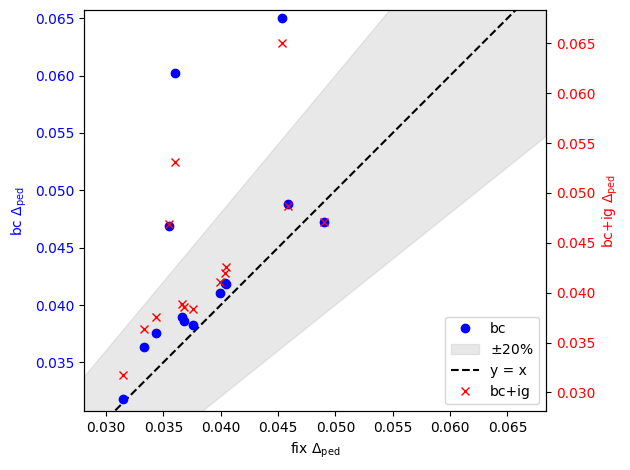

bc points (14): ['152960.03500', '153032.04475', '153140.04750', '153153.03800', '153303.03100', '153485.03500', '153489.01800', '153646.04200', '153651.03900', '153659.04350', '153661.04100', '153702.03950', '153778.02170', '153783.02600']
bc+ig points (14): ['152960.03500', '153032.04475', '153140.04750', '153153.03800', '153303.03100', '153485.03500', '153489.01800', '153646.04200', '153651.03900', '153659.04350', '153661.04100', '153702.03950', '153778.02170', '153783.02600']


In [3]:
# Pedestal width (ped_wid): bc & bc+ig vs fix
def load_ped_wid(run_dir):
    """Return {equil_id: ped_wid} for equilibria with success_outdict.npy."""
    out = {}
    for name in sorted(os.listdir(run_dir)):
        fpath = os.path.join(run_dir, name, 'success_outdict.npy')
        if os.path.isfile(fpath):
            od = np.load(fpath, allow_pickle=True).item()
            out[name] = float(od['ped_wid'])
    return out

bc_wid = load_ped_wid(bc_dir)
bcig_wid = load_ped_wid(bcig_dir)
fix_wid = load_ped_wid(fix_dir)

bc_tags_w = sorted(set(bc_wid) & set(fix_wid))
bcig_tags_w = sorted(set(bcig_wid) & set(fix_wid))

fix_bc_w = np.array([fix_wid[t] for t in bc_tags_w])
bc_vals_w = np.array([bc_wid[t] for t in bc_tags_w])
fix_bcig_w = np.array([fix_wid[t] for t in bcig_tags_w])
bcig_vals_w = np.array([bcig_wid[t] for t in bcig_tags_w])

fig, ax = plt.subplots()
ax2 = ax.twinx()

ax.plot(fix_bc_w, bc_vals_w, 'o', color='blue', label='bc', zorder=3)
ax2.plot(fix_bcig_w, bcig_vals_w, 'x', color='red', label='bc+ig', zorder=3)

all_vals_w = np.concatenate([fix_bc_w, bc_vals_w, fix_bcig_w, bcig_vals_w])
lo_w, hi_w = float(np.min(all_vals_w)), float(np.max(all_vals_w))
pad_w = 0.1 * (hi_w - lo_w) if hi_w > lo_w else 0.001
lims_w = (lo_w - pad_w, hi_w + pad_w)
ax.set_xlim(lims_w)
ax.set_ylim(lims_w)
ax2.set_ylim(lims_w)

x_line_w = np.linspace(lims_w[0], lims_w[1], 200)
ax.fill_between(x_line_w, 0.8 * x_line_w, 1.2 * x_line_w,
                 color='0.75', alpha=0.35, label=r'$\pm 20\%$', zorder=0)
ax.plot(x_line_w, x_line_w, 'k--', label='y = x', zorder=1)

ax.set_xlabel(r'fix $\Delta_{\mathrm{ped}}$')
ax.set_ylabel(r'bc $\Delta_{\mathrm{ped}}$', color='blue')
ax2.set_ylabel(r'bc+ig $\Delta_{\mathrm{ped}}$', color='red')
ax.tick_params(axis='y', labelcolor='blue')
ax2.tick_params(axis='y', labelcolor='red')

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='best')
ax.set_aspect('equal', adjustable='datalim')
fig.tight_layout()
plt.show()

print(f'bc points ({len(bc_tags_w)}): {bc_tags_w}')
print(f'bc+ig points ({len(bcig_tags_w)}): {bcig_tags_w}')


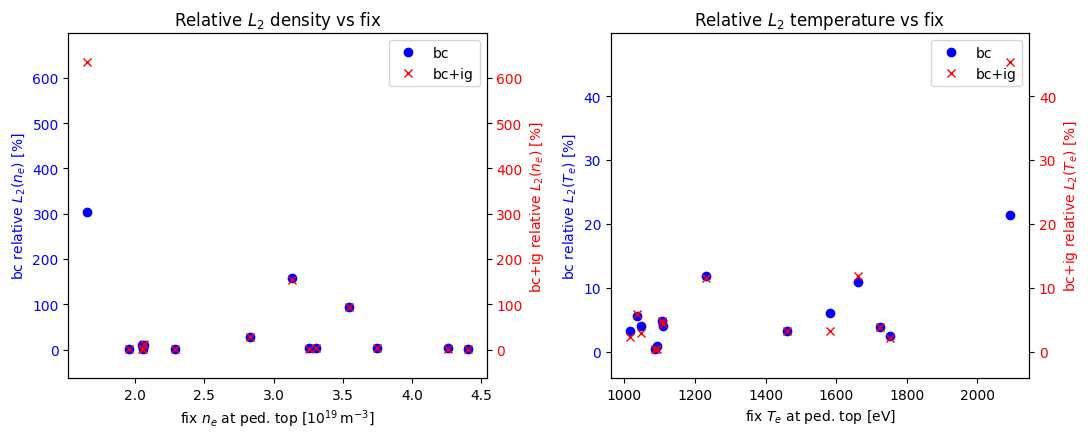

bc points (14): ['152960.03500', '153032.04475', '153140.04750', '153153.03800', '153303.03100', '153485.03500', '153489.01800', '153646.04200', '153651.03900', '153659.04350', '153661.04100', '153702.03950', '153778.02170', '153783.02600']
bc+ig points (14): ['152960.03500', '153032.04475', '153140.04750', '153153.03800', '153303.03100', '153485.03500', '153489.01800', '153646.04200', '153651.03900', '153659.04350', '153661.04100', '153702.03950', '153778.02170', '153783.02600']
L2(ne) bc: [  2.94047437   3.30509581  28.14542136   0.66667252 303.45218409
   4.41909145 157.24225056  10.37068706   1.20783291  10.69127937
   2.32727315   2.33791501   3.63539482  94.12086947]
L2(ne) bc+ig: [2.93500282e+00 8.38325415e-01 2.81469444e+01 5.04615033e-01
 6.34484416e+02 3.35414444e+00 1.53359717e+02 2.27114946e+00
 1.80644765e+00 1.21752638e+01 2.28487118e+00 1.39228515e+00
 7.56621235e-01 9.41234780e+01]
L2(Te) bc: [ 4.87197781  3.25731316  3.20156135  5.67036507 21.42899375  0.86533758
 11.8

In [4]:
# L2 profile differences (ne, Te) of bc & bc+ig vs fix, on a common psi_N grid
from glob import glob

def latest_iter_path(equil_dir):
    paths = glob(os.path.join(equil_dir, 'ne_and_Te_iter_*.npy'))
    if not paths:
        return None
    def iter_num(p):
        return int(os.path.basename(p).replace('ne_and_Te_iter_', '').replace('.npy', ''))
    return max(paths, key=iter_num)

def load_profiles_psiN(equil_dir):
    """Load latest iter; return ne(psi_N), Te(psi_N) both on ascending psi_N grids.

    Uses saved ``psi_N_ne`` (density grid) and ``psi_N`` (Te grid) from the solution.
    """
    fpath = latest_iter_path(equil_dir)
    if fpath is None:
        return None
    sol = np.load(fpath, allow_pickle=True).item()
    psi_N_Te = np.asarray(sol['psi_N'], dtype=float)
    Te = np.asarray(sol['T_e'], dtype=float)
    ne = np.asarray(sol['y'], dtype=float)
    if 'psi_N_ne' not in sol:
        raise KeyError(
            f"{fpath} missing 'psi_N_ne'; re-run with profiles_loop_solve that saves it"
        )
    psi_N_ne = np.asarray(sol['psi_N_ne'], dtype=float)
    order = np.argsort(psi_N_ne)
    return {
        'psi_N_ne': psi_N_ne[order],
        'ne': ne[order],
        'psi_N_Te': psi_N_Te,
        'Te': Te,
    }

def l2_dist(psi_a, y_a, psi_b, y_b, n_grid=400):
    """Relative L2 difference (%) of profile a vs reference b on a common psi_N interval.

    Returns 100 * ||y_a - y_b||_2 / ||y_b||_2, with ||·||_2 = sqrt(∫ (·)^2 dψ_N).
    """
    lo = max(float(np.min(psi_a)), float(np.min(psi_b)))
    hi = min(float(np.max(psi_a)), float(np.max(psi_b)))
    if hi <= lo:
        return np.nan
    grid = np.linspace(lo, hi, n_grid)
    ya = np.interp(grid, psi_a, y_a)
    yb = np.interp(grid, psi_b, y_b)
    num = float(np.sqrt(np.trapezoid((ya - yb) ** 2, grid)))
    den = float(np.sqrt(np.trapezoid(yb ** 2, grid)))
    if den == 0.0:
        return np.nan
    return 100.0 * num / den

# Successful equilibria in each case (have success_outdict + iter files)
def success_tags(run_dir):
    tags = []
    for name in sorted(os.listdir(run_dir)):
        ed = os.path.join(run_dir, name)
        if (os.path.isdir(ed)
                and os.path.isfile(os.path.join(ed, 'success_outdict.npy'))
                and latest_iter_path(ed) is not None):
            tags.append(name)
    return tags

bc_tags_p = sorted(set(success_tags(bc_dir)) & set(success_tags(fix_dir)))
bcig_tags_p = sorted(set(success_tags(bcig_dir)) & set(success_tags(fix_dir)))

def collect_l2(tags, other_dir):
    """For each tag: relative L2 (%) of other vs fix, plus fix ped-top ne/Te."""
    l2_ne, l2_Te, ne_fix_top, Te_fix_top = [], [], [], []
    for tag in tags:
        fix_p = load_profiles_psiN(os.path.join(fix_dir, tag))
        oth_p = load_profiles_psiN(os.path.join(other_dir, tag))
        # Pedestal-top scalars from fix (inner edge of density domain)
        psi_top = float(fix_p['psi_N_ne'][0])
        ne_fix_top.append(float(np.interp(psi_top, fix_p['psi_N_ne'], fix_p['ne'])) / 1e19)
        Te_fix_top.append(float(np.interp(psi_top, fix_p['psi_N_Te'], fix_p['Te'])))
        l2_ne.append(l2_dist(oth_p['psi_N_ne'], oth_p['ne'] / 1e19,
                             fix_p['psi_N_ne'], fix_p['ne'] / 1e19))
        l2_Te.append(l2_dist(oth_p['psi_N_Te'], oth_p['Te'],
                             fix_p['psi_N_Te'], fix_p['Te']))
    return (np.array(ne_fix_top), np.array(Te_fix_top),
            np.array(l2_ne), np.array(l2_Te))

ne_x_bc, Te_x_bc, l2ne_bc, l2Te_bc = collect_l2(bc_tags_p, bc_dir)
ne_x_bcig, Te_x_bcig, l2ne_bcig, l2Te_bcig = collect_l2(bcig_tags_p, bcig_dir)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# --- density L2 ---
ax = axes[0]
ax2 = ax.twinx()
ax.plot(ne_x_bc, l2ne_bc, 'o', color='blue', label='bc', zorder=3)
ax2.plot(ne_x_bcig, l2ne_bcig, 'x', color='red', label='bc+ig', zorder=3)
all_l2ne = np.concatenate([l2ne_bc, l2ne_bcig])
ylo, yhi = float(np.nanmin(all_l2ne)), float(np.nanmax(all_l2ne))
ypad = 0.1 * (yhi - ylo) if yhi > ylo else 0.01
ax.set_ylim(ylo - ypad, yhi + ypad)
ax2.set_ylim(ylo - ypad, yhi + ypad)
ax.set_xlabel(r'fix $n_e$ at ped. top [$10^{19}\,\mathrm{m}^{-3}$]')
ax.set_ylabel(r'bc relative $L_2(n_e)$ [%]', color='blue')
ax2.set_ylabel(r'bc+ig relative $L_2(n_e)$ [%]', color='red')
ax.tick_params(axis='y', labelcolor='blue')
ax2.tick_params(axis='y', labelcolor='red')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='best')
ax.set_title(r'Relative $L_2$ density vs fix')

# --- temperature L2 ---
ax = axes[1]
ax2 = ax.twinx()
ax.plot(Te_x_bc, l2Te_bc, 'o', color='blue', label='bc', zorder=3)
ax2.plot(Te_x_bcig, l2Te_bcig, 'x', color='red', label='bc+ig', zorder=3)
all_l2Te = np.concatenate([l2Te_bc, l2Te_bcig])
ylo, yhi = float(np.nanmin(all_l2Te)), float(np.nanmax(all_l2Te))
ypad = 0.1 * (yhi - ylo) if yhi > ylo else 0.01
ax.set_ylim(ylo - ypad, yhi + ypad)
ax2.set_ylim(ylo - ypad, yhi + ypad)
ax.set_xlabel(r'fix $T_e$ at ped. top [eV]')
ax.set_ylabel(r'bc relative $L_2(T_e)$ [%]', color='blue')
ax2.set_ylabel(r'bc+ig relative $L_2(T_e)$ [%]', color='red')
ax.tick_params(axis='y', labelcolor='blue')
ax2.tick_params(axis='y', labelcolor='red')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='best')
ax.set_title(r'Relative $L_2$ temperature vs fix')

fig.tight_layout()
plt.show()

print(f'bc points ({len(bc_tags_p)}): {bc_tags_p}')
print(f'bc+ig points ({len(bcig_tags_p)}): {bcig_tags_p}')
print('L2(ne) bc:', l2ne_bc)
print('L2(ne) bc+ig:', l2ne_bcig)
print('L2(Te) bc:', l2Te_bc)
print('L2(Te) bc+ig:', l2Te_bcig)


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


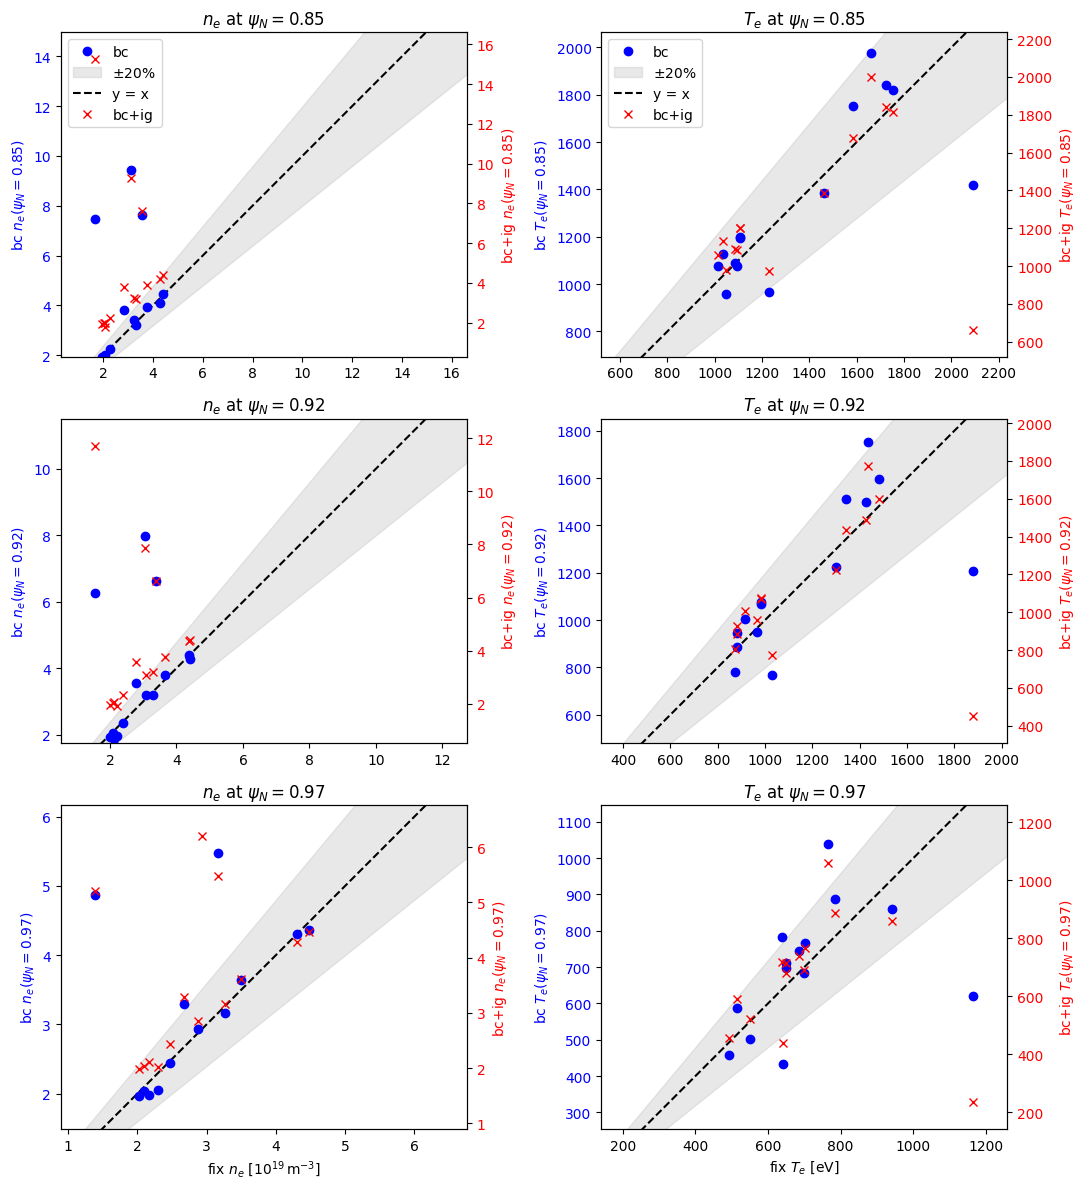

In [5]:
# ne & Te at psi_N = 0.85, 0.92, 0.97: bc & bc+ig vs fix (3x2 twin-axis)
psi_targets = [0.85, 0.92, 0.97]

def sample_at_psiN(prof, psi_N):
    """Interpolate ne [1e19 m^-3] and Te [eV] onto a target psi_N."""
    ne = float(np.interp(psi_N, prof['psi_N_ne'], prof['ne'])) / 1e19
    Te = float(np.interp(psi_N, prof['psi_N_Te'], prof['Te']))
    return ne, Te

def collect_at_psiN(tags, other_dir, psi_N):
    """Return fix/other ne and Te at psi_N for each tag (other = bc or bc+ig)."""
    fix_ne, oth_ne, fix_Te, oth_Te = [], [], [], []
    for tag in tags:
        fix_p = load_profiles_psiN(os.path.join(fix_dir, tag))
        oth_p = load_profiles_psiN(os.path.join(other_dir, tag))
        fne, fTe = sample_at_psiN(fix_p, psi_N)
        one, oTe = sample_at_psiN(oth_p, psi_N)
        fix_ne.append(fne); oth_ne.append(one)
        fix_Te.append(fTe); oth_Te.append(oTe)
    return (np.array(fix_ne), np.array(oth_ne),
            np.array(fix_Te), np.array(oth_Te))

fig, axes = plt.subplots(3, 2, figsize=(11, 12))

for irow, psi_N in enumerate(psi_targets):
    fix_ne_bc, bc_ne, fix_Te_bc, bc_Te = collect_at_psiN(bc_tags_p, bc_dir, psi_N)
    fix_ne_bcig, bcig_ne, fix_Te_bcig, bcig_Te = collect_at_psiN(bcig_tags_p, bcig_dir, psi_N)

    # --- density column ---
    ax = axes[irow, 0]
    ax2 = ax.twinx()
    ax.plot(fix_ne_bc, bc_ne, 'o', color='blue', label='bc', zorder=3)
    ax2.plot(fix_ne_bcig, bcig_ne, 'x', color='red', label='bc+ig', zorder=3)
    all_ne = np.concatenate([fix_ne_bc, bc_ne, fix_ne_bcig, bcig_ne])
    lo, hi = float(np.min(all_ne)), float(np.max(all_ne))
    pad = 0.1 * (hi - lo) if hi > lo else 0.01
    lims = (lo - pad, hi + pad)
    ax.set_xlim(lims); ax.set_ylim(lims); ax2.set_ylim(lims)
    x_line = np.linspace(lims[0], lims[1], 200)
    ax.fill_between(x_line, 0.8 * x_line, 1.2 * x_line,
                     color='0.75', alpha=0.35,
                     label=r'$\pm 20\%$' if irow == 0 else None, zorder=0)
    ax.plot(x_line, x_line, 'k--', label='y = x' if irow == 0 else None, zorder=1)
    ax.set_ylabel(rf'bc $n_e(\psi_N={psi_N})$', color='blue')
    ax2.set_ylabel(rf'bc+ig $n_e(\psi_N={psi_N})$', color='red')
    ax.tick_params(axis='y', labelcolor='blue')
    ax2.tick_params(axis='y', labelcolor='red')
    if irow == 0:
        lines1, labels1 = ax.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax.legend(lines1 + lines2, labels1 + labels2, loc='best')
    if irow == len(psi_targets) - 1:
        ax.set_xlabel(r'fix $n_e$ [$10^{19}\,\mathrm{m}^{-3}$]')
    ax.set_title(rf'$n_e$ at $\psi_N={psi_N}$')
    ax.set_aspect('equal', adjustable='datalim')

    # --- temperature column ---
    ax = axes[irow, 1]
    ax2 = ax.twinx()
    ax.plot(fix_Te_bc, bc_Te, 'o', color='blue', label='bc', zorder=3)
    ax2.plot(fix_Te_bcig, bcig_Te, 'x', color='red', label='bc+ig', zorder=3)
    all_Te = np.concatenate([fix_Te_bc, bc_Te, fix_Te_bcig, bcig_Te])
    lo, hi = float(np.min(all_Te)), float(np.max(all_Te))
    pad = 0.1 * (hi - lo) if hi > lo else 1.0
    lims = (lo - pad, hi + pad)
    ax.set_xlim(lims); ax.set_ylim(lims); ax2.set_ylim(lims)
    x_line = np.linspace(lims[0], lims[1], 200)
    ax.fill_between(x_line, 0.8 * x_line, 1.2 * x_line,
                     color='0.75', alpha=0.35,
                     label=r'$\pm 20\%$' if irow == 0 else None, zorder=0)
    ax.plot(x_line, x_line, 'k--', label='y = x' if irow == 0 else None, zorder=1)
    ax.set_ylabel(rf'bc $T_e(\psi_N={psi_N})$', color='blue')
    ax2.set_ylabel(rf'bc+ig $T_e(\psi_N={psi_N})$', color='red')
    ax.tick_params(axis='y', labelcolor='blue')
    ax2.tick_params(axis='y', labelcolor='red')
    if irow == 0:
        lines1, labels1 = ax.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax.legend(lines1 + lines2, labels1 + labels2, loc='best')
    if irow == len(psi_targets) - 1:
        ax.set_xlabel(r'fix $T_e$ [eV]')
    ax.set_title(rf'$T_e$ at $\psi_N={psi_N}$')
    ax.set_aspect('equal', adjustable='datalim')

fig.tight_layout()
plt.show()


# Convergence plots

['152960.03500', '153032.04475', '153140.04750', '153153.03800', '153303.03100', '153440.01725', '153485.03500', '153489.01800', '153646.04200', '153649.03950', '153651.03900', '153657.04100', '153659.04350', '153661.04100', '153682.02750', '153702.03950', '153778.02170', '153779.02140', '153780.02209', '153783.02600', '153822.02000', '153823.02900', '153824.04700', '153826.02950', '153827.02700', '153828.02500', '153829.03050', '153830.02500', '153831.02500', '153832.04200', '153833.03000', '153834.02900', '153837.02850', '153839.04000', '153840.02800', '153841.03100', '154083.04300', '154372.04000', '154406.04400', '154521.02800', '154526.02051', '154842.04100', '154849.02075', '154853.04015', '154856.03450', '154863.05500', '154864.03300', '154929.02200', '154959.02500', '155537.04000', '155623.03300', '156823.04300', '156826.04300', '156827.04300', '156855.04500', '156859.04500', '156864.03600', '156867.02000', '157102.02000', '157109.01963', '157188.02060', '157191.02060', '157263

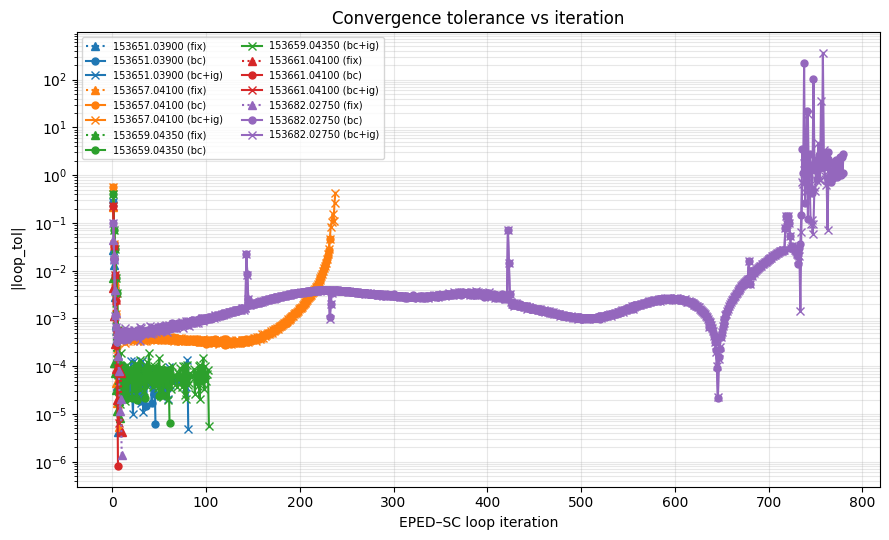

In [10]:
# Loop tolerance vs iteration for each equilibrium / BC case
from glob import glob

def load_tol_history(equil_dir):
    """Return (iters, |loop_tol|) from ne_and_Te_iter_*.npy (skips iters without loop_tol)."""
    paths = glob(os.path.join(equil_dir, 'ne_and_Te_iter_*.npy'))
    if not paths:
        return np.array([]), np.array([])
    rows = []
    for p in paths:
        it = int(os.path.basename(p).replace('ne_and_Te_iter_', '').replace('.npy', ''))
        sol = np.load(p, allow_pickle=True).item()
        if 'loop_tol' not in sol:
            continue
        rows.append((it, abs(float(sol['loop_tol']))))
    if not rows:
        return np.array([]), np.array([])
    rows.sort(key=lambda r: r[0])
    iters, tols = zip(*rows)
    return np.array(iters), np.array(tols)

case_specs = [
    ('fix', fix_dir, dict(linestyle=':', marker='^', markersize=6, fillstyle='full')),
    ('bc', bc_dir, dict(linestyle='-', marker='o', markersize=5, fillstyle='full')),
    ('bc+ig', bcig_dir, dict(linestyle='-', marker='x', markersize=6)),
]

# Equilibria present in any of the three case directories
all_tags = sorted(set().union(
    *(os.listdir(d) for _, d, _ in case_specs if os.path.isdir(d))
))
all_tags = [t for t in all_tags
            if any(os.path.isdir(os.path.join(d, t)) for _, d, _ in case_specs)]
print(all_tags)

# choose only one or a few tags
all_tags = all_tags[10:15]

cmap = plt.cm.tab10
colors = {tag: cmap(i % 10) for i, tag in enumerate(all_tags)}

fig, ax = plt.subplots(figsize=(9, 5.5))
for tag in all_tags:
    for label, run_dir, style in case_specs:
        equil_dir = os.path.join(run_dir, tag)
        if not os.path.isdir(equil_dir):
            continue
        iters, tols = load_tol_history(equil_dir)
        if len(iters) == 0:
            continue
        ax.plot(iters, tols, color=colors[tag], label=f'{tag} ({label})',
                **style, zorder=3)

ax.set_yscale('log')
ax.set_xlabel('EPED–SC loop iteration')
ax.set_ylabel(r'$|\mathrm{loop\_tol}|$')
ax.set_title('Convergence tolerance vs iteration')
# Compact legend: color = equilibrium, marker/ls = BC case
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc='best', fontsize=7, ncol=2)
ax.grid(True, which='both', alpha=0.3)
fig.tight_layout()
plt.show()


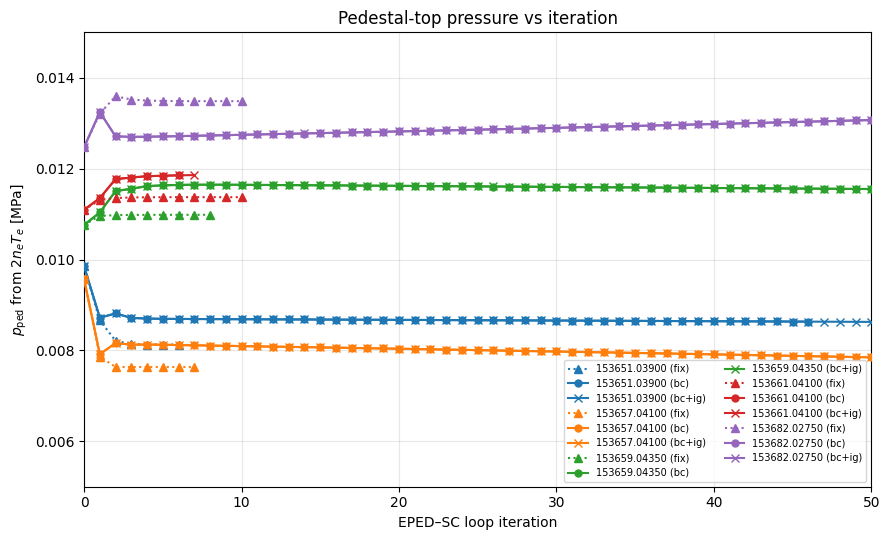

In [16]:
# Pedestal-top pressure vs iteration (from ne × Te profiles; same layout as tol plot)
eV_to_J = 1.602176634e-19

def load_pped_history(equil_dir):
    """Return (iters, p_ped [MPa]) from each ne_and_Te_iter_*.npy.

    Pressure is total pedestal-top pressure assuming n_i=n_e, T_i=T_e:
        p = 2 n_e T_e e   evaluated at the inner edge of the density grid
        (psi_N_ne[0], typically ~0.85), converted to MPa.
    """
    paths = glob(os.path.join(equil_dir, 'ne_and_Te_iter_*.npy'))
    if not paths:
        return np.array([]), np.array([])
    rows = []
    for p in paths:
        it = int(os.path.basename(p).replace('ne_and_Te_iter_', '').replace('.npy', ''))
        sol = np.load(p, allow_pickle=True).item()
        ne = np.asarray(sol['y'], dtype=float)
        Te = np.asarray(sol['T_e'], dtype=float)          # eV
        psi_Te = np.asarray(sol['psi_N'], dtype=float)
        if 'psi_N_ne' in sol:
            psi_ne = np.asarray(sol['psi_N_ne'], dtype=float)
        else:
            raise KeyError(f"{p} missing psi_N_ne")
        order = np.argsort(psi_ne)
        psi_ne, ne = psi_ne[order], ne[order]
        psi_top = float(psi_ne[0])
        ne_top = float(ne[0])
        Te_top = float(np.interp(psi_top, psi_Te, Te))
        p_mpa = (2.0 * ne_top * Te_top * eV_to_J) / 1e6
        rows.append((it, p_mpa))
    rows.sort(key=lambda r: r[0])
    iters, pp = zip(*rows)
    return np.array(iters), np.array(pp)

# Reuse case_specs / all_tags from the tolerance cell when available
if 'case_specs' not in dir():
    case_specs = [
        ('fix', fix_dir, dict(linestyle=':', marker='^', markersize=6, fillstyle='full')),
        ('bc', bc_dir, dict(linestyle='-', marker='o', markersize=5, fillstyle='full')),
        ('bc+ig', bcig_dir, dict(linestyle='-', marker='x', markersize=6)),
    ]
if 'all_tags' not in dir() or len(all_tags) == 0:
    all_tags = sorted(set().union(
        *(os.listdir(d) for _, d, _ in case_specs if os.path.isdir(d))
    ))
    all_tags = [t for t in all_tags
                if any(os.path.isdir(os.path.join(d, t)) for _, d, _ in case_specs)]

cmap = plt.cm.tab10
colors = {tag: cmap(i % 10) for i, tag in enumerate(all_tags)}

fig, ax = plt.subplots(figsize=(9, 5.5))
for tag in all_tags:
    for label, run_dir, style in case_specs:
        equil_dir = os.path.join(run_dir, tag)
        if not os.path.isdir(equil_dir):
            continue
        iters, pped = load_pped_history(equil_dir)
        if len(iters) == 0:
            continue
        ax.plot(iters, pped, color=colors[tag], label=f'{tag} ({label})',
                **style, zorder=3)

ax.set_xlabel('EPED–SC loop iteration')
ax.set_ylabel(r'$p_{\mathrm{ped}}$ from $2 n_e T_e$ [MPa]')
ax.set_title('Pedestal-top pressure vs iteration')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc='best', fontsize=7, ncol=2)
ax.grid(True, which='both', alpha=0.3)
ax.set_ylim([0.005,0.0150])
ax.set_xlim([0,50])
fig.tight_layout()
plt.show()
